<a href="https://colab.research.google.com/github/AkhilaSunesh/Epoch_Data_Science_Bootcamp/blob/main/Day4Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 4
**Name:** Akhila Sunesh <br>
**Date:** 25th July 2026 <br>
**Time:** 2:15pm

# Spotify Tracks Dataset — EDA & Data Storytelling

**Dataset:** [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

## Contents
1. Data loading & structure
2. Data cleaning (missing values, duplicates)
3. Descriptive statistics
4. Relationships between features
5. Visualizations & storytelling (7 charts, 6 chart types)
6. Summary of findings


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 25)

df = pd.read_csv("dataset.csv", index_col=0)
df.shape


(114000, 20)

## 1. Structure of the dataset


In [30]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

## 2. Missing values & duplicates


In [32]:
df.isna().sum()[df.isna().sum() > 0]

,0
artists,1
album_name,1
track_name,1


In [33]:
df[df.isna().any(axis=1)]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [34]:
print("Fully duplicated rows:", df.duplicated().sum())
df_clean = df.drop_duplicates().dropna().reset_index(drop=True)
df_clean.shape

Fully duplicated rows: 450


(113549, 20)

## 3. Descriptive statistics

In [35]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,113549.0,33.324433,22.283855,0.000,17.0000,35.000000,50.0000,100.000
duration_ms,113549.0,228081.370844,106413.098525,8586.000,174184.0000,213000.000000,261588.0000,5237295.000
danceability,113549.0,0.567031,0.173409,0.000,0.4560,0.580000,0.6950,0.985
energy,113549.0,0.642091,0.251053,0.000,0.4730,0.685000,0.8540,1.000
key,113549.0,5.309452,3.560147,0.000,2.0000,5.000000,8.0000,11.000
loudness,113549.0,-8.243408,5.011422,-49.531,-9.9980,-6.997000,-5.0010,4.532
mode,113549.0,0.637866,0.480620,0.000,0.0000,1.000000,1.0000,1.000
speechiness,113549.0,0.084674,0.105762,0.000,0.0359,0.048900,0.0845,0.965
acousticness,113549.0,0.314064,0.331906,0.000,0.0168,0.168000,0.5960,0.996
instrumentalness,113549.0,0.155703,0.309217,0.000,0.0000,0.000041,0.0487,1.000


In [36]:
df_clean['explicit'].value_counts(normalize=True).mul(100).round(1)

,proportion
explicit,
False,91.4
True,8.6


In [37]:
df_clean['track_genre'].nunique(), df_clean.groupby('track_genre').size().describe()

(114,
 count     114.000000
 mean      996.043860
 std        11.844412
 min       904.000000
 25%       998.000000
 50%       999.000000
 75%      1000.000000
 max      1000.000000
 dtype: float64)

## 4. Relationships between features


In [38]:
feature_cols = ['popularity','danceability','energy','loudness','speechiness',
                'acousticness','instrumentalness','liveness','valence','tempo']
corr = df_clean[feature_cols].corr()
corr['popularity'].sort_values(ascending=False)

,popularity
popularity,1.000000
loudness,0.047368
danceability,0.034407
tempo,0.012187
energy,-0.002447
liveness,-0.005668
acousticness,-0.022356
valence,-0.041097
speechiness,-0.045463
instrumentalness,-0.094718


## 5. Visualizations & Storytelling


### 5.1 Distribution of Track Popularity (Histogram)

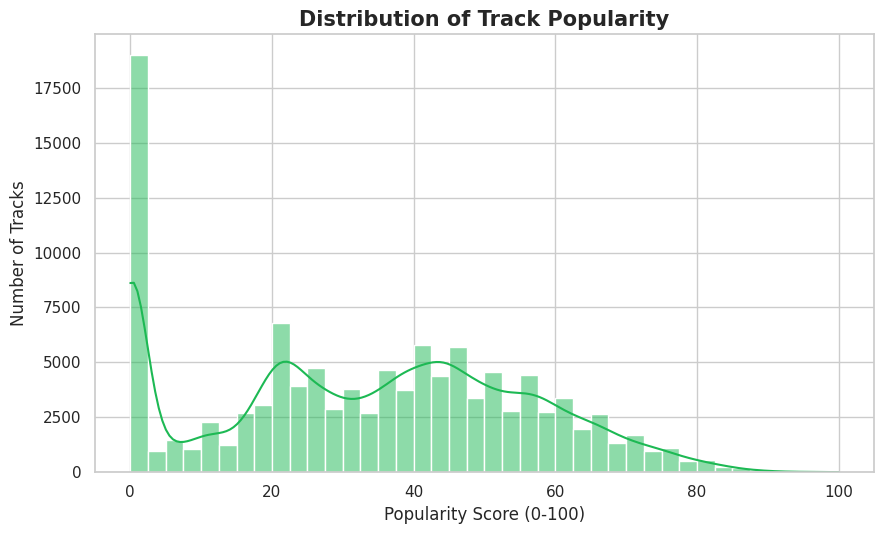

In [40]:
import os

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.histplot(df_clean['popularity'], bins=40, kde=True, color="#1DB954", ax=ax)
ax.set_title("Distribution of Track Popularity", fontsize=15, weight='bold')
ax.set_xlabel("Popularity Score (0-100)")
ax.set_ylabel("Number of Tracks")
plt.tight_layout()

# Create the 'images' directory if it doesn't exist
if not os.path.exists('images'):
    os.makedirs('images')

plt.savefig("images/01_popularity_distribution.png", dpi=150)
plt.show()

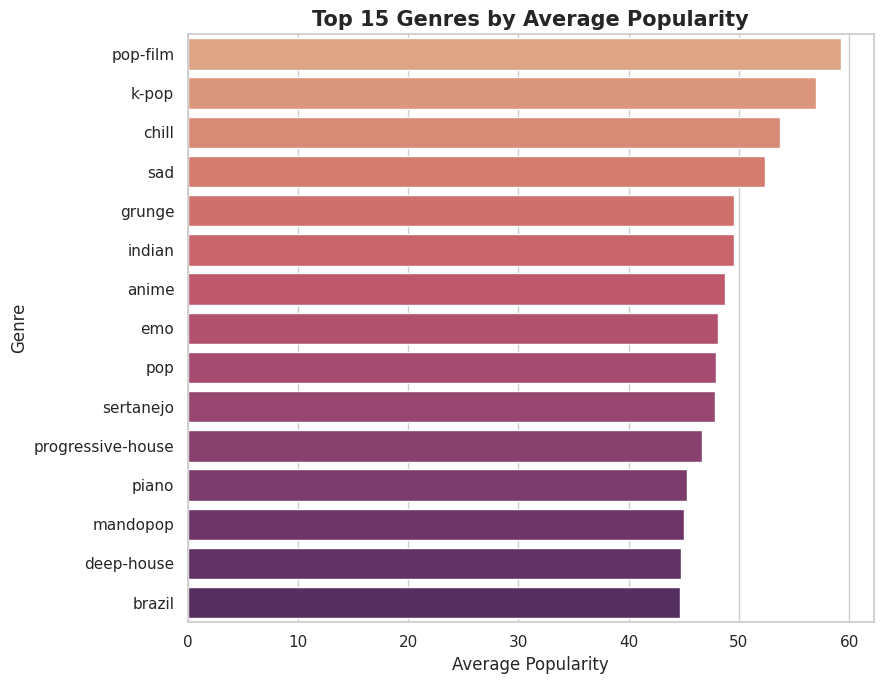

In [41]:
genre_pop = df_clean.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=genre_pop.values, y=genre_pop.index, hue=genre_pop.index, palette="flare", legend=False, ax=ax)
ax.set_title("Top 15 Genres by Average Popularity", fontsize=15, weight='bold')
ax.set_xlabel("Average Popularity")
ax.set_ylabel("Genre")
plt.tight_layout()
plt.savefig("images/02_top_genres_popularity.png", dpi=150)
plt.show()

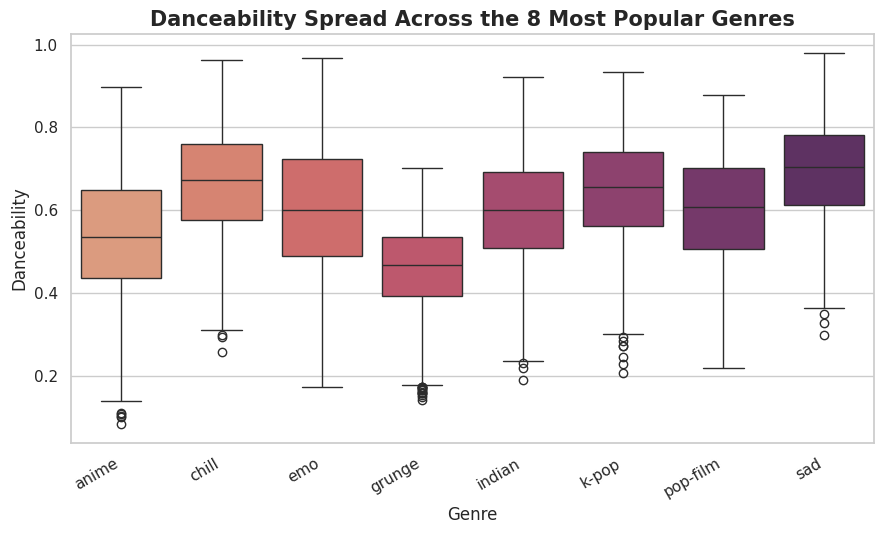

In [42]:
top8 = genre_pop.head(8).index
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df_clean[df_clean['track_genre'].isin(top8)], x='track_genre', y='danceability',
            hue='track_genre', palette="flare", legend=False, ax=ax)
ax.set_title("Danceability Spread Across the 8 Most Popular Genres", fontsize=15, weight='bold')
ax.set_xlabel("Genre")
ax.set_ylabel("Danceability")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("images/03_danceability_boxplot.png", dpi=150)
plt.show()

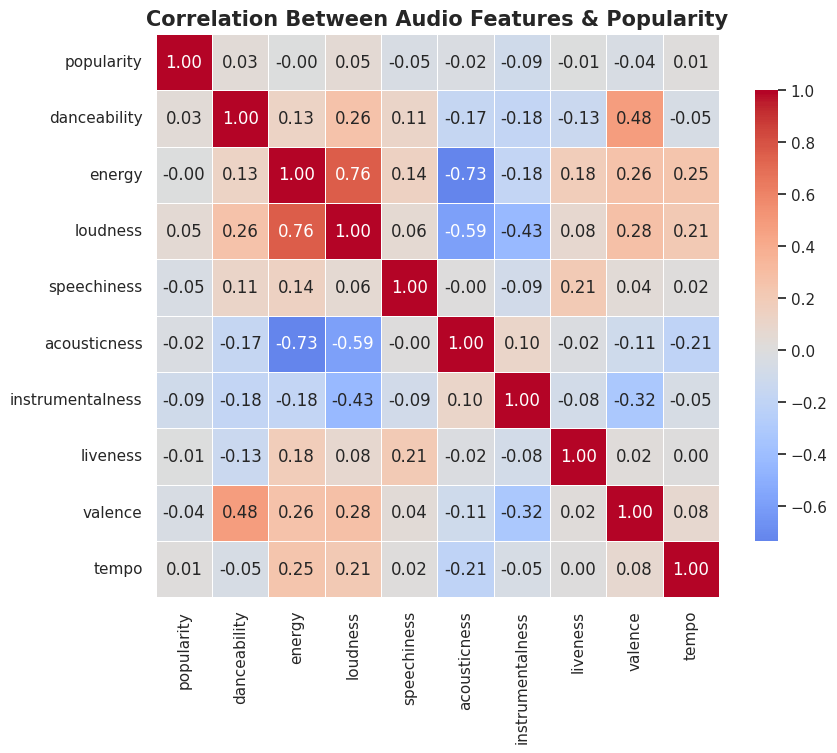

In [43]:
corr = df_clean[feature_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Between Audio Features & Popularity", fontsize=15, weight='bold')
plt.tight_layout()
plt.savefig("images/04_correlation_heatmap.png", dpi=150)
plt.show()

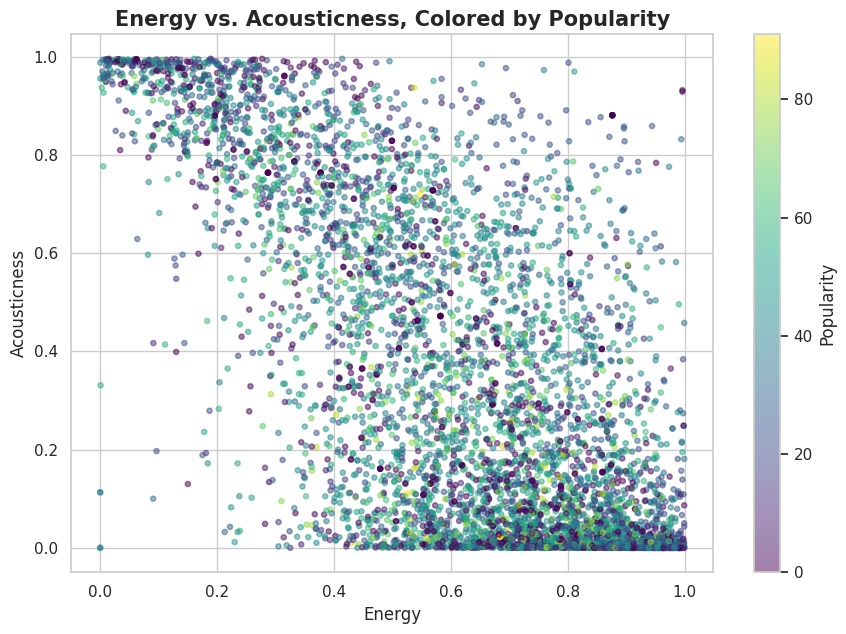

In [44]:
sample = df_clean.sample(6000, random_state=42)
fig, ax = plt.subplots(figsize=(9, 6.5))
sc = ax.scatter(sample['energy'], sample['acousticness'], c=sample['popularity'],
                 cmap='viridis', alpha=0.5, s=14)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Popularity")
ax.set_title("Energy vs. Acousticness, Colored by Popularity", fontsize=15, weight='bold')
ax.set_xlabel("Energy")
ax.set_ylabel("Acousticness")
plt.tight_layout()
plt.savefig("images/05_energy_acousticness_scatter.png", dpi=150)
plt.show()

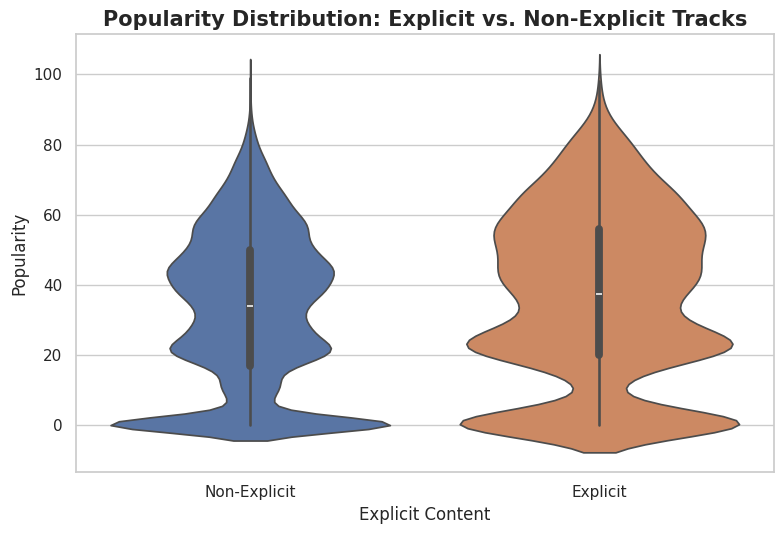

In [45]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.violinplot(data=df_clean, x='explicit', y='popularity', hue='explicit',
               palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)
ax.set_title("Popularity Distribution: Explicit vs. Non-Explicit Tracks", fontsize=15, weight='bold')
ax.set_xlabel("Explicit Content")
ax.set_ylabel("Popularity")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Non-Explicit", "Explicit"])
plt.tight_layout()
plt.savefig("images/06_explicit_violin.png", dpi=150)
plt.show()

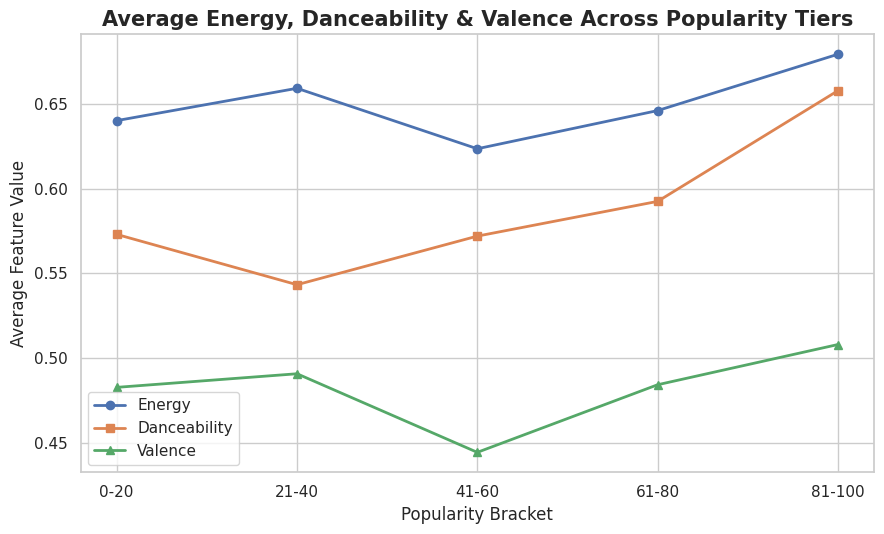

In [46]:
df_clean['pop_bin'] = pd.cut(df_clean['popularity'], bins=[-1,20,40,60,80,100],
                        labels=['0-20','21-40','41-60','61-80','81-100'])
trend = df_clean.groupby('pop_bin', observed=True)[['energy','danceability','valence']].mean()
fig, ax = plt.subplots(figsize=(9, 5.5))
for col, marker in zip(trend.columns, ['o','s','^']):
    ax.plot(trend.index.astype(str), trend[col], marker=marker, linewidth=2, label=col.capitalize())
ax.set_title("Average Energy, Danceability & Valence Across Popularity Tiers", fontsize=15, weight='bold')
ax.set_xlabel("Popularity Bracket")
ax.set_ylabel("Average Feature Value")
ax.legend()
plt.tight_layout()
plt.savefig("images/07_feature_trend_by_popularity.png", dpi=150)
plt.show()